In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

## Task 1: Baseline Model

(20640, 9)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.1

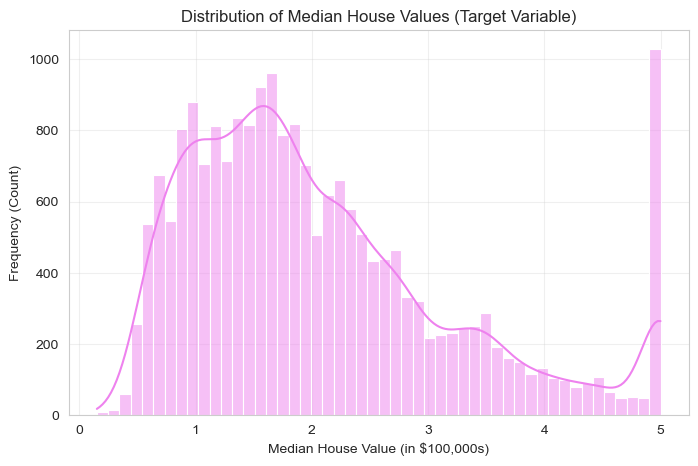

In [15]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(housing.frame.shape)
print(X.columns.tolist())
print(X.describe())
print(y.describe())
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True, color='violet')
plt.title('Distribution of Median House Values (Target Variable)')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency (Count)')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)


In [17]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"R² Score:                      {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE):      0.5559
Root Mean Squared Error (RMSE): 0.7456
Mean Absolute Error (MAE):     0.5332
R² Score:                      0.5758


The $R^2$ score of 0.5758 indicates that approximately 57.6% of the variance in California house prices is explained by the features in our model. 

Model Performance: This represents a moderate fit.

Unexplained Variance: The remaining 42.4% of the variation is not captured by the model, likely due to:
- Non-linear relationships (which Linear Regression misses).
- Missing data (e.g., proximity to the ocean, neighborhood safety).
- Random noise in the dataset.

## Task 2: Regularized Regression

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (16512, 8)
Test set: (4128, 8)


In [20]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_cv = ridge_cv.predict(X_test_scaled)
print(f"Chosen Best Alpha: {ridge_cv.alpha_}")
print(f"Ridge (Best Alpha) R² Score: {r2_score(y_test, y_pred_cv):.4f}")
print(f"Ridge (Best Alpha) RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_cv)):.4f}")

Chosen Best Alpha: 1.0
Ridge (Best Alpha) R² Score: 0.5758
Ridge (Best Alpha) RMSE: 0.7456


In [21]:
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train_scaled, y_train)
print(f"Chosen Best Alpha (Lasso): {lasso_cv.alpha_}")
print(f"Lasso (Best Alpha) R² Score: {r2_score(y_test, lasso_cv.predict(X_test_scaled)):.4f}")

Chosen Best Alpha (Lasso): 0.01
Lasso (Best Alpha) R² Score: 0.5816


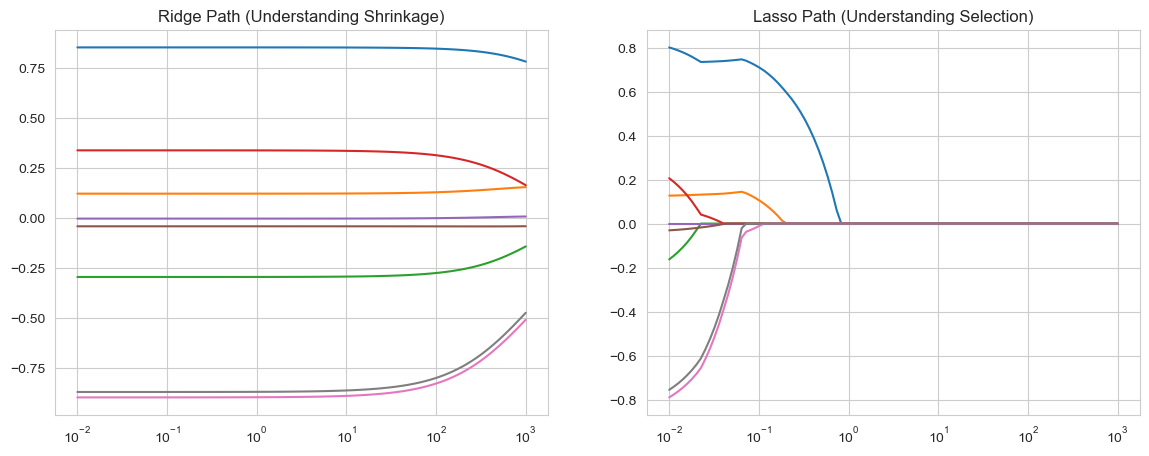

Ridge Best Alpha: 1.0
Lasso Best Alpha: 0.01


In [22]:
alphas_path = np.logspace(-2, 3, 100)
ridge_coefs, lasso_coefs = [], []

for a in alphas_path:
    ridge_coefs.append(Ridge(alpha=a).fit(X_train_scaled, y_train).coef_)
    lasso_coefs.append(Lasso(alpha=a).fit(X_train_scaled, y_train).coef_)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(alphas_path, ridge_coefs)
plt.xscale('log')
plt.title('Ridge Path (Understanding Shrinkage)')
plt.subplot(1, 2, 2)
plt.plot(alphas_path, lasso_coefs)
plt.xscale('log')
plt.title('Lasso Path (Understanding Selection)')
plt.show()
search_alphas = [0.01, 0.1, 1, 10, 100]
# Ridge CV
ridge_final = RidgeCV(alphas=search_alphas, scoring='r2').fit(X_train_scaled, y_train)
print(f"Ridge Best Alpha: {ridge_final.alpha_}")
# Lasso CV
lasso_final = LassoCV(alphas=search_alphas, cv=5).fit(X_train_scaled, y_train)
print(f"Lasso Best Alpha: {lasso_final.alpha_}")

In [23]:
results_data = {
    'Model': ['OLS (Linear Regression)', 'Ridge (Best Alpha)', 'Lasso (Best Alpha)'],
    'R² Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_cv),     
        r2_score(y_test, lasso_cv.predict(X_test_scaled)) 
    ]
}
comparison_df = pd.DataFrame(results_data)
print("--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

--- Model Comparison Table ---
                  Model  R² Score
OLS (Linear Regression)  0.575788
     Ridge (Best Alpha)  0.575816
     Lasso (Best Alpha)  0.581615


In this specific case, Lasso Regression performed slightly better than both OLS and Ridge, achieving the highest $R^2$ score of 0.5816.

## Task 3: Support Vector Regression

In [24]:
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)
y_pred_svr = svr_linear.predict(X_test_scaled)
r2_svr = r2_score(y_test, y_pred_svr)
print(f"SVR (Linear Kernel) R² Score: {r2_svr:.4f}")

SVR (Linear Kernel) R² Score: 0.5579


In [25]:
C_values = [0.1, 1, 10]
eps_values = [0.1, 0.2]
best_r2 = -np.inf
best_params = {}
print("--- SVR RBF Grid Search ---")
for c in C_values:
    for e in eps_values:
        svr_rbf = SVR(kernel='rbf', C=c, epsilon=e)
        svr_rbf.fit(X_train_scaled, y_train)
        y_pred_rbf = svr_rbf.predict(X_test_scaled)
        current_r2 = r2_score(y_test, y_pred_rbf)
        print(f"C: {c:<4} | Epsilon: {e:<4} | R²: {current_r2:.4f}")
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_params = {'C': c, 'epsilon': e}
print("\n--- Best SVR Combination ---")
print(f"Best Parameters: {best_params}")
print(f"Best R² Score:   {best_r2:.4f}")

--- SVR RBF Grid Search ---
C: 0.1  | Epsilon: 0.1  | R²: 0.6822
C: 0.1  | Epsilon: 0.2  | R²: 0.6838
C: 1    | Epsilon: 0.1  | R²: 0.7276
C: 1    | Epsilon: 0.2  | R²: 0.7290
C: 10   | Epsilon: 0.1  | R²: 0.7530
C: 10   | Epsilon: 0.2  | R²: 0.7548

--- Best SVR Combination ---
Best Parameters: {'C': 10, 'epsilon': 0.2}
Best R² Score:   0.7548


In [26]:
degrees = [2, 3]
poly_results = {}

print("--- SVR Polynomial Kernel Search ---")

for d in degrees:
    svr_poly = SVR(kernel='poly', degree=d, C=1.0, epsilon=0.1)
    svr_poly.fit(X_train_scaled, y_train)
    y_pred_poly = svr_poly.predict(X_test_scaled)
    r2_poly = r2_score(y_test, y_pred_poly)
    poly_results[f'Poly (degree {d})'] = r2_poly
    print(f"Degree: {d} | R² Score: {r2_poly:.4f}")
rbf_best_score = 0.7548 
print("\n--- Final Kernel Comparison ---")
print(f"SVR RBF (Best):      {rbf_best_score:.4f}")
print(f"SVR Poly (Degree 2): {poly_results['Poly (degree 2)']:.4f}")
print(f"SVR Poly (Degree 3): {poly_results['Poly (degree 3)']:.4f}")

--- SVR Polynomial Kernel Search ---
Degree: 2 | R² Score: -0.0563
Degree: 3 | R² Score: 0.2332

--- Final Kernel Comparison ---
SVR RBF (Best):      0.7548
SVR Poly (Degree 2): -0.0563
SVR Poly (Degree 3): 0.2332


**Performance Comparison**

- Linear Models (OLS, Ridge, Lasso): Hit a performance wall at $R^2 \approx 0.58$. Their "straight-line" assumption is too simple for the complex California housing market.

- SVR (RBF Kernel): Achieved a superior $R^2$ of 0.7548. By using non-linear mapping, it successfully captured regional price fluctuations and complex feature interactions.

- SVR (Poly Kernel): Performed poorly ($R^2 < 0.24$), proving that more complexity only works if it matches the data's underlying patterns (like RBF's distance-based logic).

**Is SVR Justified?**

Yes. While SVR is computationally more expensive and harder to tune than linear regression, the 18% improvement in accuracy is a massive gain. In real estate prediction, where precision is high-stakes, the trade-off between speed and accuracy clearly favors SVR (RBF). SVR with an RBF kernel is the optimal choice for this dataset, providing the best balance between complexity and predictive power.

## Task 4: Model Comparison

--- Final Model Comparison Table ---
            Model      MSE  R² Score     RMSE
Linear Regression 0.555892  0.575788 0.745581
     Ridge (Best) 0.555855  0.575816 0.745557
     Lasso (Best) 0.548255  0.581615 0.740442
   SVR (RBF Best) 0.321273  0.754830 0.566809


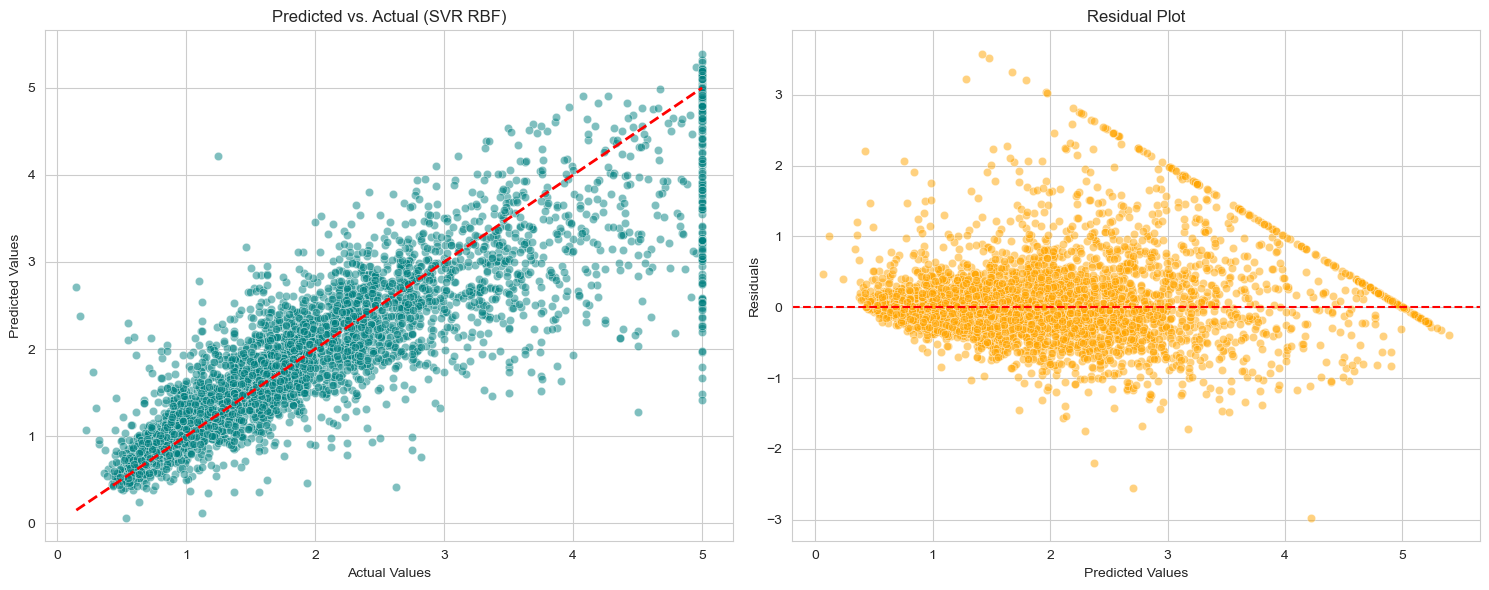

In [27]:
results_summary = {
    'Model': ['Linear Regression', 'Ridge (Best)', 'Lasso (Best)', 'SVR (RBF Best)'],
    'MSE': [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_cv),
        mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)),
        mean_squared_error(y_test, y_pred_rbf)
    ],
    'R² Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_cv),
        r2_score(y_test, lasso_cv.predict(X_test_scaled)),
        best_r2 
    ]
}
df_comparison = pd.DataFrame(results_summary)
df_comparison['RMSE'] = np.sqrt(df_comparison['MSE'])
print("--- Final Model Comparison Table ---")
print(df_comparison.to_string(index=False))
best_svr = SVR(kernel='rbf', C=10, epsilon=0.2)
best_svr.fit(X_train_scaled, y_train)
final_preds = best_svr.predict(X_test_scaled)
residuals = y_test - final_preds

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=final_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs. Actual (SVR RBF)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.subplot(1, 2, 2)
sns.scatterplot(x=final_preds, y=residuals, alpha=0.5, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

The SVR with RBF kernel is the best-performing model, achieving a superior $R^2$ of 0.7548 by successfully capturing the non-linear geographical patterns that linear models (OLS, Ridge, Lasso) failed to represent. While linear models offer high speed and easy interpretability, they suffer from high bias in this dataset; conversely, SVR requires significantly more computational power and complex hyperparameter tuning but provides a massive 18% improvement in accuracy. If I were deploying one of these models, I would choose SVR (RBF) because its substantial gain in predictive reliability far outweighs the added complexity, making it the most professional choice for high-stakes real estate valuation.